# Comet backward integration

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import rebound
import assist

In [71]:
ephem = assist.Ephem("../data/linux_p1550p2650.440", "../data/sb441-n16.bsp")

In [72]:
# Finding a long period comet
for i in range(100):
    ic = np.genfromtxt('COM_LPCs.csv', delimiter=',')[i]
    _, q, e, inc, node, argPeri, epoch, t_p, _ = ic
    a=q/(1.0-e)
    if not np.isinf(a) and a>200:
        break


/var/folders/ng/rdf4kxy9665116xvjhjvfkl80000gn/T/ipykernel_43955/2573496062.py:5: RuntimeWarning: divide by zero encountered in double_scalars
  a=q/(1.0-e)


In [73]:
sim = rebound.Simulation()
extras = assist.Extras(sim, ephem)
t_initial = (2400000.0 + epoch) - ephem.jd_ref
sim.t = t_initial

# barycentric coordinates?
Mtot = 0.0
for i in range(11):
    Mtot += ephem.get_particle(i, t_initial).m
primary = rebound.Particle(m=Mtot)
initial = rebound.Particle(primary=primary, simulation=sim, a=q/(1.0-e), e=e, inc=inc/180.0*np.pi, Omega=node/180.0*np.pi, omega=argPeri/180.0*np.pi, T=t_p)
sim.add(initial)

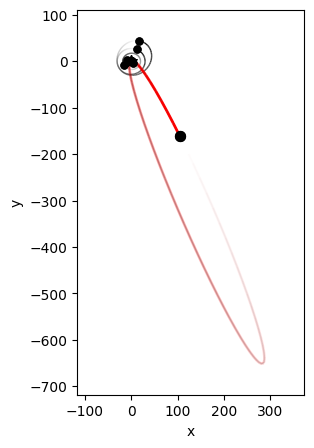

In [74]:
sim2 = assist.simulation_convert_to_rebound(sim,ephem)
op1 = rebound.OrbitPlot(sim2)
op2 = rebound.OrbitPlot(sim2, particles=[-1], ax=op1.ax, fig=op1.fig, lw=2, color="red")

In [75]:
deltaT = 10.0
oi = sim.particles[0].orbit(primary=primary)
sim.integrate(sim.t+deltaT)
of = sim.particles[0].orbit(primary=primary)
initialInwards = False
if oi.d > of.d:
    # Moving inwards initially
    initialInwards = True
    print("io")
while oi.d < of.d or initialInwards==True:
    oi = sim.particles[0].orbit(primary=primary)
    sim.integrate(sim.t+deltaT)
    of = sim.particles[0].orbit(primary=primary)
    if initialInwards==True:
        if oi.d < of.d:
            initialInwards = False
    else:
        if oi.d > oi.d:
            # Turned around
            print("1/a at d=%.1f:" % of.d, 1./of.a)
        if of.d>250.0:
            # Hit 250AU
            print("1/a at d=%.1f:" % of.d, 1./of.a)
            break
    

1/a at d=250.0: 0.002745098178634979


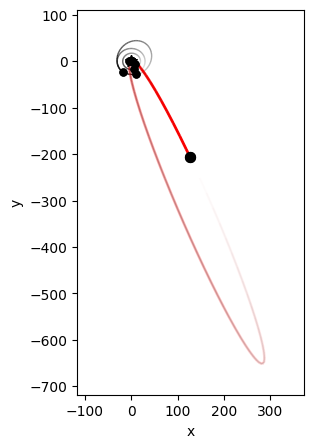

In [76]:
sim2 = assist.simulation_convert_to_rebound(sim,ephem)
op1 = rebound.OrbitPlot(sim2)
op2 = rebound.OrbitPlot(sim2, particles=[-1], ax=op1.ax, fig=op1.fig, lw=2, color="red")